# Dataset

In [1]:
import pandas as pd

def get_full_dataset_from_file(file_path: str):
    """
    Read features and labels from parquet file.

    Parameters:
        file_path (str): The path to parquet file.

    Returns:
        feats (np.ndarray): shape (N, num_features)
        labels (np.ndarray): shape (N,)
    """
    data = pd.read_parquet(file_path).to_numpy()
    return data[:, :-1], data[:, -1]

train_feats, train_labels = get_full_dataset_from_file('../extracted_features/train.parquet')
valid_feats, valid_labels = get_full_dataset_from_file('../extracted_features/validation.parquet')
test_sample_feats, test_sample_labels = get_full_dataset_from_file('../extracted_features/test_sample.parquet')
test_feats = pd.read_parquet('../extracted_features/test.parquet').to_numpy()

# Model

In [ ]:
!python -m pip install lightgbm

###  1. Model configuration

In [ ]:
import lightgbm as lgb
from sklearn.metrics import accuracy_score, f1_score

lgbm_model = lgb.LGBMClassifier(
    n_estimators=1000, 
    learning_rate=0.025,
    num_leaves=15,       
    random_state=42,
    verbosity=-1,
    scale_pos_weight=0.33,  
)

### 2. Training

In [49]:
_model = lgbm_model # Choose a model to use
feats = [1, 2, 3, 4] # Choosing features for training,
num_train_samples = 200000 # Choose number of training samples, in range (0, 500000]

_model.fit(train_feats[:num_train_samples, feats], train_labels[:num_train_samples])

,boosting_type,'gbdt'
,num_leaves,15
,max_depth,-1
,learning_rate,0.025
,n_estimators,1000
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


### 3. Adaptive thresholding

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve
import numpy as np
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(labels, preds):
    """
    Draw confusion matrix of the predictions and the true labels.

    Arguments:
        labels (np.ndarray): list of true labels.
        preds (np.ndarray): list of model predictions.
    """
    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Human', 'AI'], 
                yticklabels=['Human', 'AI'])
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

def find_best_threshold(y_probs: np.ndarray, labels: np.ndarray):
    """
    Find the best threshold for AI probability, which gives the highest F1-macro score.A

    Arguments:
        y_probs (np.darray): Shape (N, 2), model predicted probabilities.
        labels (np.darray): Shape (N), correct labels.
    
    Returns:
        (float): The best threshold.
    """
    # Apply different thresholds to the AI prob
    thresholds = np.linspace(0, 1, 100)
    f1_macro_scores = [f1_score(labels, y_probs[:, 1] >= t, average='macro') for t in thresholds]

    # Draw diagram
    plt.figure(figsize=(8, 5))
    plt.plot(thresholds, f1_macro_scores, color='blue', lw=2)
    best_t = thresholds[np.argmax(f1_macro_scores)]
    plt.axvline(best_t, color='red', linestyle='--', label=f'Best Threshold: {best_t:.2f}')
    plt.title(f'F1-macro vs Threshold (Max: {max(f1_macro_scores):.4f})')
    plt.xlabel('Threshold (AI)'); plt.ylabel('F1-macro'); plt.legend(); plt.show()

    return best_t

c:\Users\Dell\miniconda3\envs\torchcuda\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


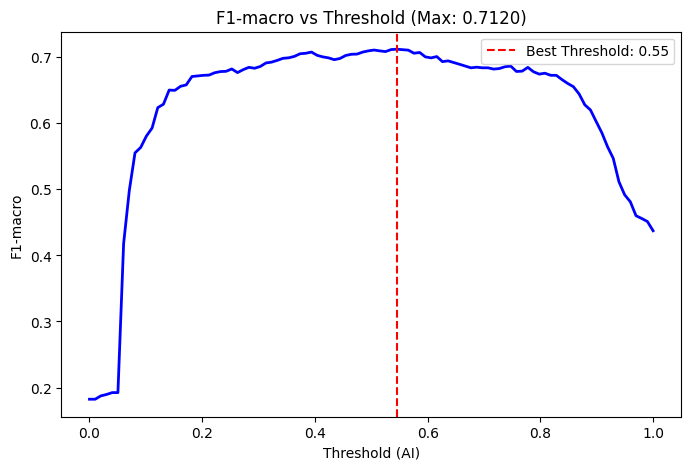

Accuracy: 77.40%
F1-score: 0.7119933121278852


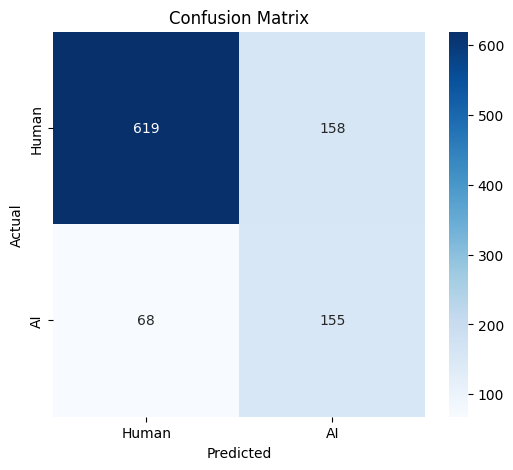

In [50]:
# Output probabilities
y_probs = _model.predict_proba(test_sample_feats[:, feats])
best_t = find_best_threshold(y_probs, test_sample_labels)

# Predictions based on the selected threshold
y_pred = y_probs[:, 1] > best_t
print(f"Accuracy: {accuracy_score(test_sample_labels, y_pred) * 100:.2f}%")
print(f"F1-score: {f1_score(test_sample_labels, y_pred, average='macro')}")
plot_confusion_matrix(test_sample_labels, y_pred)

### 4. Predict on real test and save Submission file

In [51]:
import pandas as pd

test_predictions = _model.predict(test_feats[:, feats]).astype(int)
test_probs = _model.predict_proba(test_feats[:, feats])[:, 1]
test_predictions = test_probs >= best_t

ids = pd.read_parquet('../data/test.parquet', columns=["ID"])["ID"].values
df = pd.DataFrame({
    "ID": ids,   
    "label": test_predictions
})

df.to_csv("submission.csv", index=False)

c:\Users\Dell\miniconda3\envs\torchcuda\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Dell\miniconda3\envs\torchcuda\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
